# 引入 GAN

在这个框架中，LSTM 模型扮演生成器（Generator）的角色，我们需要额外构建一个判别器（Discriminator）来区分真实数据对和生成数据对。

1. 训练判别器：让判别器学会区分真实对和生成对
1. 训练生成器：通过判别器的损失，让生成器学会产生更逼真的预测（欺骗判别器）
1. 交替训练：两者博弈，共同进步

## 1 基于FGSM的对抗训练

**FGSM: Fast Gradient Sign Method / 快速梯度符号法**

> reference: [ArXiv: Explaining and Harnessing Adversarial Examples](https://arxiv.org/abs/1412.6572)

对抗性训练的思想起源于“对抗攻击”。它的核心逻辑是这样的：

1. **攻击**：我们刻意地在输入数据上添加一些微小的、人类难以察觉的噪声（即扰动）。
1. **欺骗**：这些精心构造的噪声（被称为对抗样本）虽然看起来和原始数据几乎一样，却能轻易地“欺骗”模型，让模型做出完全错误的预测（例如，把你的负荷预测值改得很大）。
1. **防御（即对抗性训练）**：为了防范这种攻击，我们在训练模型时，主动地把这些“对抗样本”也加入到训练数据中，并告诉模型：“看，这是加了噪声的数据，但它的真实标签应该和原数据一样”。通过这种方式，模型被迫去学习数据更本质的特征，而不是仅仅拟合训练数据中的表面模式，从而变得更鲁棒、泛化能力更强。

------

- 原理：对于每个训练样本 `X`，我们计算当前模型预测的损失函数 `Loss` 关于输入 `X` 的梯度。然后，我们沿着梯度上升的方向（即让损失增加的方向）对 `X` 施加一个微小的扰动，得到对抗样本 `X_adv`。
  
$$
X_{adv} = X + \epsilon \cdot \text{sign}(\nabla_X L(f, X, y))
$$

- 训练：把 (`X_adv`, `y`) 这个对抗样本对也加入到训练过程中。模型需要同时学会预测原始数据和对扰动后的数据。
- 这相当于主动给模型“喂毒”，迫使它的决策边界变得更加平滑，对输入数据的微小变化不再敏感。这能非常有效地对抗过拟合，提升模型的泛化能力。[Liu et al. (2020)](https://iopscience.iop.org/article/10.1088/1742-6596/1570/1/012097/meta) 研究也表明，将这种对抗训练策略应用于LSTM，可以有效防止模型过拟合。

In [1]:
# 包
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# NN.py 中存放神经网络
from NN import *

# 可视化
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']  # 英文字体优先，中文回退到宋体
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学公式字体，与Times风格匹配
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号



# 数据
# -------------------- 配置参数 --------------------
from pyexpat import features


DATA_PATH = '../Data/aligned_2026_01_02.csv'                 # 数据文件
TARGET_COL = 'power'                   # 目标列名
FEATURE_COLS = None                     # 若为None则使用所有除datetime外的列
LOOKBACK = 24                           # 输入窗口（24个15分钟 = 6小时）
HORIZON = 1                           # 预测步数（1步 = 15分钟）
TEST_SIZE = 0.15                         # 测试集比例
VAL_SIZE = 0.15                          # 验证集比例（从训练集中划分）
BATCH_SIZE = 64
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
WEIGHT_DECAY = 1e-4     # 添加L2正则化（AdamW优化器）
BIDIRECTIONAL = False
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
PATIENCE = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {DEVICE}")
MODEL_SAVE_PATH = 'best_simple_lstm_model_1.pth'
SCALER_SAVE_PATH = 'simple_scaler_1.pkl'

# -------------------- 加载数据 --------------------
df = pd.read_csv(DATA_PATH, parse_dates=['datetime'])
df.sort_values('datetime', inplace=True)          # 确保时间顺序

# 特征工程：添加时间特征
df['hour'] = df['datetime'].dt.hour
# df['dayofweek'] = df['datetime'].dt.dayofweek
# 天顶角
# 'shortwave_radiation (W/m2)' 'direct_radiation (W/m2)', 'diffuse_radiation (W/m2)', 'direct_normal_irradiance (W/m2)'
df['theta'] = np.arccos( 
    (df['shortwave_radiation (W/m2)'] - df['diffuse_radiation (W/m2)']) / df['direct_normal_irradiance (W/m2)']
)
# 对小时进行周期编码
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# # 添加差分特征（捕捉变化趋势）
# df['power_diff_1h'] = df['power'].diff(4)  # 1小时的变化（4个15分钟）
# # 添加比率特征
# # df['power_to_irradiance_ratio'] = df['power'] / (df['irradiance'] + 1e-6)
# # 添加累积特征
# df['power_cumsum_6h'] = df['power'].rolling(24).sum()  # 过去6小时累计用电
# # 添加峰谷时段标识
# df['is_peak_hour'] = df['hour'].isin([10, 11, 14, 15, 16]).astype(int)  # 根据实际调整

# 宁波夏季约5:00日出，19:00日落，可保守取 6:00-18:00 为白天
# df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)
# df = df[ df['is_daytime'] == 1 ].copy()  # 仅保留白天数据
# 划分昼夜数据集
# df_day = df[df['is_daytime'] == 1].copy()
# df_night = df[df['is_daytime'] == 0].copy()



# 选择特征列
feature_cols = [ 
    'power', 
    'hour_sin', 'hour_cos', 
    # 'temperature_2m (°C)', 
    # 'et0_fao_evapotranspiration (mm)', 
    'shortwave_radiation (W/m2)', 'direct_radiation (W/m2)', 'diffuse_radiation (W/m2)', 'direct_normal_irradiance (W/m2)'
]
print("使用的特征列:", feature_cols)

# 确保目标列在特征中
assert TARGET_COL in feature_cols, "目标列必须在特征列中！"
target_idx = feature_cols.index(TARGET_COL)

# 提取特征矩阵
data_raw = df[feature_cols].values.astype(np.float32)



# -------------------- 划分数据集（按时间顺序）--------------------
n = len(data_raw)
train_end = int(n * (1 - TEST_SIZE - VAL_SIZE))
val_end = int(n * (1 - TEST_SIZE))
train_data = data_raw[:train_end]
val_data = data_raw[train_end:val_end]
test_data = data_raw[val_end:]


# -------------------- 标准化（仅基于训练集）--------------------
# scaler = StandardScaler()
scaler = MinMaxScaler()
# 注意：标准化应在序列构建之前进行，避免未来信息泄露
train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

# 保存scaler以便后续使用
joblib.dump(scaler, SCALER_SAVE_PATH)



# -------------------- 构建监督学习序列 --------------------
X_train, y_train = create_sequences(train_data_scaled, target_idx, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(val_data_scaled, target_idx, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(test_data_scaled, target_idx, LOOKBACK, HORIZON)

print(f"训练样本: {X_train.shape}, 验证样本: {X_val.shape}, 测试样本: {X_test.shape}")

# 转换为PyTorch张量
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# 创建DataLoader
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)  # 时间序列不打乱
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


使用设备: cuda
使用的特征列: ['power', 'hour_sin', 'hour_cos', 'shortwave_radiation (W/m2)', 'direct_radiation (W/m2)', 'diffuse_radiation (W/m2)', 'direct_normal_irradiance (W/m2)']
训练样本: (3940, 24, 7), 验证样本: (826, 24, 7), 测试样本: (826, 24, 7)


In [3]:
# -------------------- 初始化模型 --------------------
input_size = X_train.shape[2]          # 特征维度
model = LSTMPredictor(
    input_size=input_size,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=HORIZON,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL
)

criterion = nn.MSELoss() 
# AdamW 优化器
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)


# 关键参数：epsilon 控制对抗强度
EPSILON = 0.05 # 可以从0.01, 0.05, 0.1开始尝试

# 调用对抗训练
print(f"开始对抗性训练, epsilon={EPSILON}")
model = train_model_adversarial(
    model, train_loader, val_loader, criterion, optimizer,
    scheduler=scheduler, num_epochs=NUM_EPOCHS, patience=PATIENCE,
    device=DEVICE, model_save_path=MODEL_SAVE_PATH,
    epsilon=EPSILON # 传入epsilon
)

开始对抗性训练, epsilon=0.05
Epoch 10/100 | Train Loss (adv): 0.0069 | Val Loss: 0.0071 | LR: 0.001000
Epoch 20/100 | Train Loss (adv): 0.0053 | Val Loss: 0.0069 | LR: 0.001000
Epoch 30/100 | Train Loss (adv): 0.0047 | Val Loss: 0.0069 | LR: 0.001000
Epoch 00037: reducing learning rate of group 0 to 5.0000e-04.
Epoch 40/100 | Train Loss (adv): 0.0043 | Val Loss: 0.0069 | LR: 0.000500
Epoch 50/100 | Train Loss (adv): 0.0042 | Val Loss: 0.0069 | LR: 0.000500
Epoch 60/100 | Train Loss (adv): 0.0041 | Val Loss: 0.0068 | LR: 0.000500
Epoch 00068: reducing learning rate of group 0 to 2.5000e-04.
Epoch 70/100 | Train Loss (adv): 0.0040 | Val Loss: 0.0069 | LR: 0.000250
Early stopping at epoch 72
Adversarial Training finished. Best val loss: 0.0068 at epoch 62


In [4]:
# -------------------- 在测试集上评估 --------------------
test_loss, y_pred, y_true = evaluate_model(model, test_loader, criterion, device=DEVICE)

# StandardScaler 反标准化
# 注意：y_pred和y_true都是标准化后的值，若要计算原始功率的MAE，需反标准化
# 由于功率列是单独标准化的，我们需要取出功率列的scaler参数
# power_mean, power_std = scaler.mean_[target_idx], scaler.scale_[target_idx]
# y_pred_orig = y_pred * power_std + power_mean
# y_true_orig = y_true * power_std + power_mean

# MinMaxScaler 反标准化
power_min, power_max = scaler.data_min_[target_idx], scaler.data_max_[target_idx]
power_range = power_max - power_min
y_pred_orig = y_pred * power_range + power_min
y_true_orig = y_true * power_range + power_min

# 计算指标
mae = mean_absolute_error(y_true_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
mape = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100  # 注意处理零值
r2 = r2_score(y_true_orig, y_pred_orig)

print("\n========== 测试集结果 ==========")
print(f"测试集损失 (MSE): {test_loss:.4f}")
print(f"MAE (原始功率): {mae:.2f} kW")
print(f"RMSE (原始功率): {rmse:.2f} kW")
print(f"R2: {r2:.4f}")
# print(f"MAPE: {mape:.2f}%")
# print(f"预测准确率 (100% - MAPE): {100 - mape:.2f}%")


========== 测试集结果 ==========
测试集损失 (MSE): 0.0047
MAE (原始功率): 3.53 kW
RMSE (原始功率): 8.54 kW
R2: 0.9287


C:\Users\杉嶋桐惠\AppData\Local\Temp\ipykernel_26808\4191712090.py:20: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100  # 注意处理零值


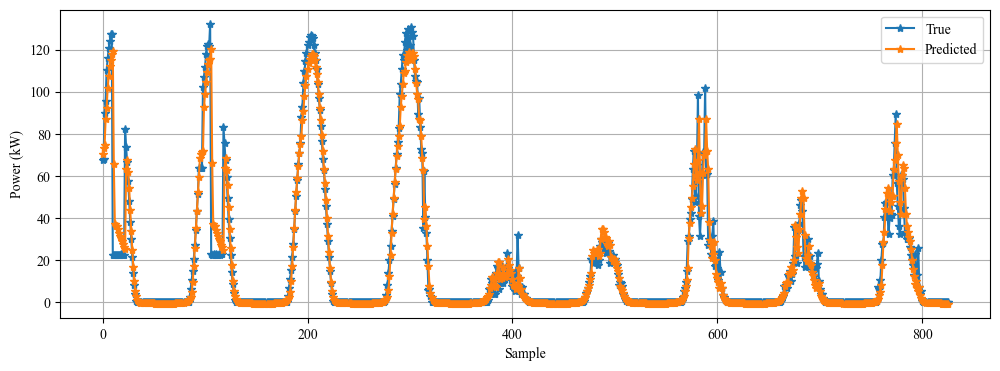

In [5]:
# 可视化 y_pred, y_true
# 绘制预测结果
plt.figure(figsize=(12, 4))
plt.plot(y_true_orig, marker='*', label='True')
plt.plot(y_pred_orig, marker='*', label='Predicted')
plt.grid()
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Power (kW)')
plt.show()

## 2 GAN

引入了一个独立的“判别器”网络。LSTM模型在这里变成了“生成器”。

------

**原理**：你有一个生成器（G），即LSTM模型，它负责生成预测结果。还有一个判别器（D），通常是一个简单的二分类网络（如MLP），它的任务是区分“真实的”数据对和“生成的”数据对。

- “真实对”：可以是 (`输入特征`, `真实负荷值`)
- “生成对”：是 (`输入特征`, `LSTM预测值`)

**训练**：这是一个二人博弈的过程。生成器（LSTM）努力让自己的预测结果看起来足够真实，以至于能骗过判别器。而判别器则努力提升自己的“鉴伪”能力。两者交替训练，共同进步。

**意义**：

[ Quilodrán-Casas et al.(2021) ](https://arxiv.org/abs/2104.06297)利用这种思想，通过对LSTM进行对抗训练，使其在潜在空间中进行预测，从而避免了生成分布外的样本，有效减少了预测随时间推移而产生的误差发散。

In [19]:
# 在训练好基础LSTM模型后，或者从头开始训练

# 参数设置
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FEATURE_DIM = len(feature_cols)  # 特征维度
HIDDEN_SIZE = 64  # LSTM隐藏层大小
LAMBDA_GAN = 0.05  # GAN损失权重（从0.05开始尝试）
LAMBDA_MSE = 1.0   # MSE损失权重
GAN_EPOCHS = 30

# 1. 准备模型
# 如果已经有训练好的LSTM模型
generator = GeneratorWithFeatures(model)  # model是你的LSTM

# 或者创建新模型
# lstm_model = LSTMPredictor(
#     input_size=FEATURE_DIM,
#     hidden_size=HIDDEN_SIZE,
#     num_layers=2,
#     output_size=1,
#     dropout=0.2
# ).to(DEVICE)

# generator = GeneratorWithFeatures(lstm_model)

# 2. 创建判别器
discriminator = Discriminator(
    feature_dim=FEATURE_DIM,
    hidden_dims=[64, 32],
    output_dim=1,
    dropout=0.2
).to(DEVICE)

# 3. 创建GAN训练器
gan_trainer = GANTrainer(generator, discriminator, device=DEVICE)

# 4. 设置优化器
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.001, weight_decay=1e-5)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0005, weight_decay=1e-5)  # 判别器学习率通常小一些
gan_trainer.set_optimizers(g_optimizer, d_optimizer)

# 5. 训练
print("开始GAN训练...")
best_generator = gan_trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=GAN_EPOCHS,
    lambda_gan=LAMBDA_GAN,
    lambda_mse=LAMBDA_MSE,
    d_steps=1,  # 每轮训练判别器1次
    g_steps=1,  # 每轮训练生成器1次
    patience=5
)

开始GAN训练...
Epoch 5/30 | G Loss: 0.0364 | D Loss: 1.3870 | D Acc Real: 0.54 | D Acc Fake: 0.45 | Val MSE: 0.0067
Epoch 10/30 | G Loss: 0.0365 | D Loss: 1.3861 | D Acc Real: 0.50 | D Acc Fake: 0.51 | Val MSE: 0.0065
Epoch 15/30 | G Loss: 0.0366 | D Loss: 1.3865 | D Acc Real: 0.50 | D Acc Fake: 0.50 | Val MSE: 0.0068
Early stopping at epoch 16


In [24]:
# 6. 测试评估
# 使用训练好的生成器（LSTM）进行预测
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_generator.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = best_generator(X_batch)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y_batch.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# 反标准化（根据scaler类型）
if hasattr(scaler, 'mean_'):  # StandardScaler
    power_mean = scaler.mean_[target_idx]
    power_std = scaler.scale_[target_idx]
    preds_orig = all_preds * power_std + power_mean
    targets_orig = all_targets * power_std + power_mean
else:  # MinMaxScaler
    power_min = scaler.data_min_[target_idx]
    power_max = scaler.data_max_[target_idx]
    power_range = power_max - power_min
    preds_orig = all_preds * power_range + power_min
    targets_orig = all_targets * power_range + power_min

# 将二维数组展平为一维（避免索引问题）
preds_orig = preds_orig.flatten()
targets_orig = targets_orig.flatten()

# 计算整体指标
mae = mean_absolute_error(targets_orig, preds_orig)
rmse = np.sqrt(mean_squared_error(targets_orig, preds_orig))
r2 = r2_score(targets_orig, preds_orig)

# 修正后的MAPE计算（只对功率大于20kW的样本计算）
mask = targets_orig > 20
if mask.sum() > 0:
    mape = np.mean(np.abs((targets_orig[mask] - preds_orig[mask]) / targets_orig[mask])) * 100
else:
    mape = np.nan

print("\n========== GAN训练后的测试结果 ==========")
print(f"MAE: {mae:.2f} kW")
print(f"RMSE: {rmse:.2f} kW")
print(f"MAPE (功率>20kW): {mape:.2f}%")
print(f"R2: {r2:.4f}")

# 可选：分功率区间计算MAPE，便于诊断
print("\n========== 分功率区间MAPE分析 ==========")
thresholds = [0, 20, 50, 100, 160]
mask = targets_orig==0
mape_seg = np.mean(np.abs((targets_orig[mask] - preds_orig[mask]) / targets_orig[mask])) * 100
print(f"功率区间 0 kW: 样本数={mask.sum()}, MAPE={mape_seg:.2f}%")
for i in range(len(thresholds)-1):
    low, high = thresholds[i], thresholds[i+1]
    mask = (targets_orig > low) & (targets_orig <= high)
    if mask.sum() > 0:
        mape_seg = np.mean(np.abs((targets_orig[mask] - preds_orig[mask]) / targets_orig[mask])) * 100
        print(f"功率区间 ({low}, {high}] kW: 样本数={mask.sum()}, MAPE={mape_seg:.2f}%")


========== GAN训练后的测试结果 ==========
MAE: 3.52 kW
RMSE: 8.68 kW
MAPE (功率>20kW): 24.41%
R2: 0.9262

========== 分功率区间MAPE分析 ==========
功率区间 0 kW: 样本数=441, MAPE=inf%
功率区间 (0, 20] kW: 样本数=149, MAPE=53.66%
功率区间 (20, 50] kW: 样本数=128, MAPE=35.80%
功率区间 (50, 100] kW: 样本数=61, MAPE=13.02%
功率区间 (100, 160] kW: 样本数=47, MAPE=8.16%


C:\Users\杉嶋桐惠\AppData\Local\Temp\ipykernel_26808\2314622633.py:58: RuntimeWarning: divide by zero encountered in divide
  mape_seg = np.mean(np.abs((targets_orig[mask] - preds_orig[mask]) / targets_orig[mask])) * 100


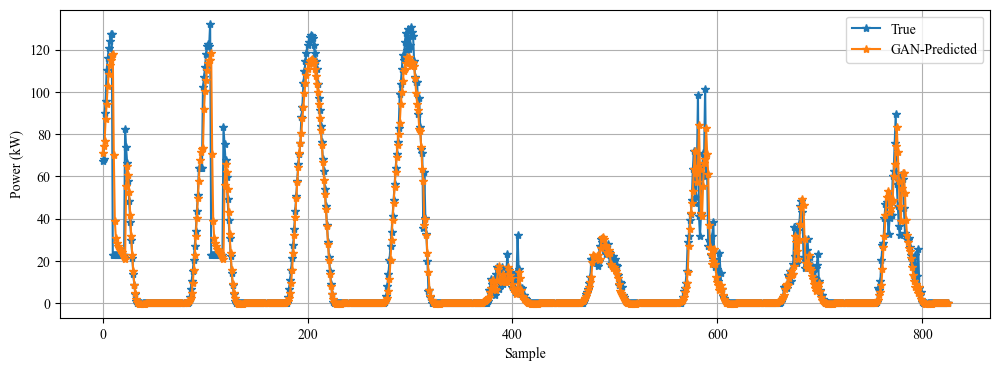

In [8]:
# 可视化 y_pred, y_true
# 绘制预测结果
plt.figure(figsize=(12, 4))

plt.plot(targets_orig, 
         label='True', 
         marker='*'
    )
# plt.plot(y_pred_orig, 
#          label='LSTM-Predicted', 
#         #  marker='*', 
#          linestyle='--'
#     )
plt.plot(preds_orig, 
         label='GAN-Predicted', 
         marker='*', 
        #  linestyle='--'
    )

plt.grid()
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Power (kW)')
plt.show()